In [ ]:
! pip install -q PyMuPDF beautifulsoup4 requests pdfplumber python-docx supabase langchain langchain-groq sentence-transformers langgraph pydantic typing-extensions langchain-community faiss-cpu

In [97]:
import os
import fitz
from bs4 import BeautifulSoup
import requests
import fitz
from io import BytesIO
import pdfplumber
import time 
import docx


from supabase.client import Client, create_client
from langchain_groq import ChatGroq 
from sentence_transformers import SentenceTransformer

from langgraph.graph import StateGraph,START, END
from pydantic import BaseModel, Field # for defining structured output for models
import operator

from typing import List, TypedDict, Literal, Annotated, Optional
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain.chains import RetrievalQA

from langchain_core.messages import SystemMessage, HumanMessage

from langchain.output_parsers import PydanticOutputParser
from langchain.prompts import PromptTemplate

from supabase.client import Client, create_client

import warnings
warnings.filterwarnings('ignore')

In [98]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

### Read the Syllabus

In [99]:
def CCI_File_reader(pathFile, fileHeaderName, dropPart=0): 
    readBook = fitz.open(pathFile)

    Book_content = ""
    for page_num, page in enumerate(readBook):

        blocks = page.get_text("blocks")
        for block in blocks: 
            tempCont = block[4].replace("\n", "")
            tempCont = tempCont.replace("\t", " ")
            tempCont = tempCont.replace("\xad", " ") 
            tempCont = tempCont.replace(".", "") 
            tempCont = tempCont.replace("  ", " ") 
            Book_content += tempCont + ". "
            
        Book_content += f" |- Page Number: {page_num} -| "
    return f"{fileHeaderName}: {Book_content}"



def CCI_docx_file_reader(pathFile, fileHeaderName, dropPart=0): 
    doc = docx.Document(pathFile)

    Book_content = ""
    for para in doc.paragraphs:
        tempCont = para.text.replace("\n", "")
        tempCont = tempCont.replace("\t", " ")
        tempCont = tempCont.replace("\xad", " ") 
        tempCont = tempCont.replace(".", "") 
        tempCont = tempCont.replace("  ", " ") 
        Book_content += tempCont + ". "

    return f"{fileHeaderName}: {Book_content}"

In [100]:
CCI_course_syllabuses = [
    CCI_File_reader("./CCI_Course_syllabus/Cloud_Computing.pdf", "Course Information about Cloud_Computing", dropPart=0), 
    CCI_File_reader("./CCI_Course_syllabus/Computer_Organization_and_Assembly_Language.pdf", "Course Information about Computer_Organization_and_Assembly_Language", dropPart=0), 
    CCI_File_reader("./CCI_Course_syllabus/Data_Structures.pdf", "Course Information about Data_Structures", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Design_Analysis_of_Algorithms.pdf", "Course Information about Design_Analysis_of_Algorithms", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Digital_Logic_Design_Laboratory.pdf", "Course Information about Digital_Logic_Design_Laboratory", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Digital_Logic_Design.pdf", "Course Information about Digital_Logic_Design", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Discrete_Structures.pdf", "Course Information about Discrete_Structures", dropPart=0),
    CCI_docx_file_reader("./CCI_Course_syllabus/Human_Computer_Interaction.docx", "Course Information about Human_Computer_Interaction", dropPart=0),
    CCI_docx_file_reader("./CCI_Course_syllabus/Introduction_to_Artificial_Intelligence.docx", "Course Information about Introduction_to_Artificial_Intelligence", dropPart=0),
    CCI_docx_file_reader("./CCI_Course_syllabus/Introduction_to_IT.docx", "Course Information about Introduction_to_IT", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Introduction_to_Database_Systems.pdf", "Course Information about Introduction_to_Database_Systems", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Networking_Fundamentals.pdf", "Course Information about Networking_Fundamentals", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Object_Oriented_Design_with_Java.pdf", "Course Information about Object_Oriented_Design_with_Java", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Operating_Systems.pdf", "Course Information about Operating_Systems", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Probability_and_Statistics.pdf", "Course Information about Probability_and_Statistics", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Prof_Ethical_Issues_in_CS.pdf", "Course Information about Prof_Ethical_Issues_in_CS", dropPart=0),
    CCI_docx_file_reader("./CCI_Course_syllabus/Programming_1.docx", "Course Information about Programming_1", dropPart=0),
    CCI_docx_file_reader("./CCI_Course_syllabus/Programming_2.docx", "Course Information about Programming_2", dropPart=0),
    CCI_docx_file_reader("./CCI_Course_syllabus/Programming_Languages_Paradigms.docx", "Course Information about Programming_Languages_Paradigms", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Topics_in_CS_Introduction_To_Machine_Learning.pdf", "Course Information about Topics_in_CS_Introduction_To_Machine_Learning", dropPart=0),
    CCI_File_reader("./CCI_Course_syllabus/Web_Programming.pdf", "Course Information about Web_Programming", dropPart=0),
    CCI_File_reader("./other_course_syllabus/Fundamentals_of_Innovation_and_Entrepreneurship.pdf", "Course Information about Fundamentals_of_Innovation_and_Entrepreneurship", dropPart=0)
]

science_course_syllabuses = [
    CCI_File_reader("./Science_Course_syllabus/Calculus_1.pdf", "Course Information about Calculus_1", dropPart=0),
    CCI_docx_file_reader("./Science_Course_syllabus/General_Chemistry_1_Lab.docx", "Course Information about General_Chemistry_1_Lab", dropPart=0),
    CCI_File_reader("./other_course_syllabus/Fundamentals_of_Innovation_and_Entrepreneurship.pdf", "Course Information about Fundamentals_of_Innovation_and_Entrepreneurship", dropPart=0)
]

other_college_course_syllabuses = [
    CCI_File_reader("./other_course_syllabus/Fundamentals_of_Innovation_and_Entrepreneurship.pdf", "Course Information about Fundamentals_of_Innovation_and_Entrepreneurship", dropPart=0)
]

In [101]:
allSyllabus = CCI_course_syllabuses + science_course_syllabuses + other_college_course_syllabuses

syllabus_vectorStore = FAISS.from_texts(allSyllabus, embeddings)
syllabus_retriver = syllabus_vectorStore.as_retriever(search_kwargs={"k":10})

def Science_And_CCI_Syllabus_RagFN(studentQuestion): 
    qa_chain_cs_docs = syllabus_retriver.get_relevant_documents(studentQuestion)

    qa_chain_cs_docsTemp = ""
    for sent in qa_chain_cs_docs: 
        if len(qa_chain_cs_docsTemp.split(" "))<25000: 
            qa_chain_cs_docsTemp += sent.page_content + " || \n"

    return qa_chain_cs_docsTemp
    

### Assign Top level LLM RAG Information Bank: ===================

In [102]:
def bookPdfDataProcessor(BookPath): 
    uoshandBook = fitz.open(BookPath)

    Book_contentInner = []
    page_contentInnder = ""

    for page_num, page in enumerate(uoshandBook):
        blocks = page.get_text("blocks")

        for block in blocks:         
            tempCont = block[4].replace("\n", "")
            tempCont = tempCont.replace("\t", " ")
            tempCont = tempCont.replace("\xad", " ") 
            page_contentInnder = page_contentInnder + tempCont

            if len(page_contentInnder.split(" "))>250: 
                Book_contentInner.append(page_contentInnder)
                page_contentInnder = ""

    if len(page_contentInnder.split(" "))>50:
        Book_contentInner.append(page_contentInnder)
        page_contentInnder = ""

    return Book_contentInner


Book_content = bookPdfDataProcessor("./topLevelAgen_InformationBank/UOS Faculty Handbook 25-26 Design.pdf") + bookPdfDataProcessor("./topLevelAgen_InformationBank/Student Handbook.pdf")
    
print(min([len(x.split(" ")) for x in Book_content]), max([len(x.split(" ")) for x in Book_content]), sum([len(x.split(" ")) for x in Book_content])/len([len(x.split(" ")) for x in Book_content]))

139 715 299.55280898876407


In [103]:
topLevelLLMInfo_bank = []
with open("./topLevelAgen_InformationBank/pdfData.txt", encoding='utf-8') as f: 
    data = f.readlines()
    for x in data:
        if len(x.split(" "))>5000: 
            po = x.split(" ")
            topLevelLLMInfo_bank.append(" ".join(po[:5000]))
            topLevelLLMInfo_bank.append(" ".join(po[5000:]))
        else:
            topLevelLLMInfo_bank.append(x)

with open("./topLevelAgen_InformationBank/webOrganizedData.txt", encoding='utf-8') as f: 
    data = f.readlines()
    for x in data:
        if len(x.split(" "))>5000: 
            po = x.split(" ")
            topLevelLLMInfo_bank.append(" ".join(po[:5000]))
            topLevelLLMInfo_bank.append(" ".join(po[5000:]))
        else:
            topLevelLLMInfo_bank.append(x)

topLevelLLMInfo_bank.extend(Book_content)


In [104]:
topLevelAgent_QNA_vectorStore = FAISS.from_texts(topLevelLLMInfo_bank, embeddings)
topLevelAgent_QNA_retriver = topLevelAgent_QNA_vectorStore.as_retriever(search_kwargs={"k":10})

In [105]:
qa_chain_cs_docs = topLevelAgent_QNA_retriver.get_relevant_documents("what department are in College of computing and informatics? ")
# qa_chain_cs_docs = "\n\n".join([d.page_content for d in qa_chain_cs_docs])

qa_chain_cs_docsTemp = ""
for sent in qa_chain_cs_docs: 
    if len(qa_chain_cs_docsTemp.split(" "))<25000: 
        qa_chain_cs_docsTemp += sent.page_content + " "

print(len(qa_chain_cs_docsTemp.split(" ")))

2240


In [106]:
# Now define a function that applies a RAG funciton for Top-Level LLM 
def TopLevelAgentRagFn(studentQuestion): 
    topLevelAgent_QNA_retriver = topLevelAgent_QNA_vectorStore.as_retriever(search_kwargs={"k":10})
    qa_chain_cs_docs = topLevelAgent_QNA_retriver.get_relevant_documents(studentQuestion)

    qa_chain_cs_docsTemp = ""
    for sent in qa_chain_cs_docs: 
        if len(qa_chain_cs_docsTemp.split(" "))<25000: 
            qa_chain_cs_docsTemp += sent.page_content + " || \n"

    return qa_chain_cs_docsTemp


### Now create the node that fetches the offered courses by colleges

In [ ]:
supabase_key  = ""
supabase_url  = ""
supabaseClient = create_client(supabase_url, supabase_key)

In [108]:
def getUniversityOfferedCourses(student_remaining_courses_in_study_pan): # use this as a norma funciton not as a node in graph
    print("2. Communicating with Other Agent and fetching Courses offered by other Colleges!!!")

    current_offered_courses_by_AllOther_College = supabaseClient.table("courses_from_othercollege").select("*").execute().data
    current_offered_courses_by_Medical_College = supabaseClient.table("courses_from_medical").select("*").execute().data
    current_offered_courses_by_CCI = supabaseClient.table("courses_from_computerscience").select("*").execute().data
    current_offered_courses_by_Science = supabaseClient.table("courses_from_science").select("*").execute().data

    print("3. Filtering the courses that has completed by this student and those courses that are not in student study plan")
    allCourses = current_offered_courses_by_AllOther_College + current_offered_courses_by_Medical_College + current_offered_courses_by_CCI + current_offered_courses_by_Science
    remaining_Courses = [course for course in allCourses if course['course_code'] in student_remaining_courses_in_study_pan]

    return remaining_Courses


### Define the LLM from GROQ: ======================

In [ ]:
groq_api_key = ""

generator_llm = ChatGroq(
    api_key = groq_api_key, 
    model_name = "meta-llama/llama-4-scout-17b-16e-instruct", # "meta-llama/llama-4-scout-17b-16e-instruct"  "llama-3.1-8b-instant",
    temperature = 0,
    max_completion_tokens = 5000,
    top_p = 1.0,
    stream = False,
    stop = None,
    # include_reasoning  = False
)

## CCI and Science basic Information and Function

In [110]:
def cci_science_agent_website_text_processor(websiteText, chunkSize=500): 
    # this Fn is implemented the rag part happening below CCI_agent and Science_agent to process basic_QNA operation from website
    websiteText_splitted = websiteText.split(" ")
    websiteText_arr = []
    for x in range(0, len(websiteText_splitted), chunkSize): 
        start=x 
        end = x+chunkSize
        if end >=len(websiteText_splitted): 
            end = len(websiteText_splitted)
        datass = " ".join(websiteText_splitted[start : end])
        websiteText_arr.append(datass)
    
    return websiteText_arr

# define the state for the model

In [111]:
class UOS_AgentState(BaseModel): 
    uid: str
    mensOrWomCampus: Literal['mens', 'womens']
    standing: Literal["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]
    yearOfStudy: Literal[1,2,3,4,5]
    semester: Literal[1,2,3,4,5,6,7,8,9,10]
    college: Literal[
        "College of Science", 
        "College of Computing and Informatics"
    ]
    department: Literal[
        "BSc_Mathematics", 
        "BSc_Chemistry", 
        "BSc_Petroleum_Geosciences_and_Remote_Sensing", 
        "BSc_Biotechnology", 
        "BSc_Business_Information_Systems", 
        "BSc_IT_Multimedia", 
        "BSc_Computer_Science", 
        "BSc_Cybersecurity", 
        "BSc_Computer_Engineering",
        "BSc_Applied_Physics"
    ]
    studentAlreadyCompletedCourses : List[str] =[]
    StudentAlreadyCompletedCredits : int = 0
    student_query : str

    
    # below student course related states : will be filled by topLevel_student_studyPlan_getter_Node()
    remaining_course_in_study_plan: List[dict] = []
    remaining_elective_course_in_study_plan: List[dict] = []
    remaining_Study_plan_courseIds: List[str] = []


    # agent decision states: below None is for just for redundancy
    UOS_AgentState_top_level_decision: Literal["ScienceAgent", "CCIAgent"] = None
    topLevelAgent_basicConversationOrNot: bool = None
    basic_Conversation_answer : str = None
    topLevel_CCIScience_Agent_Req_Info_Holder: List = []



    # CCI agent states: =====================================================================================
    UOS_AgentState_CCIAgent_decision: Literal["CCI_Conversation", "CCI_CourseScheduling_advising"] = None
    CCI_weblink_state : str = None
    CCI_weblink_Content : str = None
    CCI_Basic_QNA_RAG_Answer: str = None
    CCI_FinalScheduler_texts_LLM: str = None # related to course scheduling advising

    CCI_Requesting_Info_from_Science_Agent: bool = False
    CCI_Requesting_Info_from_TopLevel_Agent: bool = False


    # Science agent states: ================================================================================
    UOS_AgentState_ScienceAgent_decision: Literal["Science_Conversation", "Science_CourseScheduling_advising"] = None
    Science_weblink_state : str = None
    Science_weblink_Content : str = None
    Science_Basic_QNA_RAG_Answer: str = None
    Science_FinalScheduler_texts_LLM: str = None # related to course scheduling advising

    Science_Requesting_Info_from_CCI_Agent: bool = False
    Science_Requesting_Info_from_TopLevel_Agent: bool = False




    CCI_Science_Routing_done:bool = False
    CCI_TopLevelAgent_Routing_done:bool = False
    Science_CCI_Routing_done:bool = False
    Science_TopLevelAgent_Routing_done:bool = False

### Work with top-level Agent: ==================

In [112]:
class UOS_AgentState_top_level(BaseModel):
    basicConversationOrNot: bool = Field(
        description="True if the student is engaging in general conversation, False if the user is asking about academic advising or course scheduling or course registering."
    )
    academicAdvising: Optional[Literal["ScienceAgent", "CCIAgent"]] = Field(
        description="ScienceAgent if the user is from College of Science, CCIAgent if the user is from College of Computing and Informatics. Null if not applicable."
    )

In [113]:
topLevel_Parser = PydanticOutputParser(pydantic_object=UOS_AgentState_top_level)

topLevel_Agent_prompt = PromptTemplate(
    template=(
        "You are an AI academic advisor and general conversation assistant for the University of Sharjah.\n"
        "Your role is to identify the *type* of query a student is making — whether it is a general/basic conversation, "
        "or an academic/advising query related to their college or department.\n\n"

        "=== UNIVERSITY INFORMATION ===\n"
        "COLLEGE OF SCIENCE includes:\n"
        " - Department of Applied Biology → B.Sc in Biotechnology\n"
        " - Department of Chemistry → B.Sc in Chemistry\n"
        " - Department of Mathematics → B.Sc in Mathematics\n"
        " - Department of Applied Physics and Astronomy → B.Sc in Petroleum Geosciences and Remote Sensing, B.Sc in Applied Physics\n\n"

        "COLLEGE OF COMPUTING AND INFORMATICS includes:\n"
        " - Department of Computer Engineering → B.Sc in Computer Engineering, B.Sc in Cybersecurity Engineering\n"
        " - Department of Computer Science → B.Sc in Computer Science, B.Sc in Information Technology Multimedia, B.Sc in Biomedical Informatics\n"
        " - Department of Information Systems → B.Sc in Business Information Systems\n\n"

        "=== YOUR TASK ===\n"
        "Analyze the student's query and classify it into one of the following categories:\n\n"
        "1. **General/Basic Conversation** — The query is casual, social, or unrelated to academics, course registration, or specific colleges.\n"
        "   → Set `basicConversationOrNot = True`\n"
        "   → Set `academicAdvising = null`\n\n"

        "2. **Academic or College-Specific Query** — The query is about academic advising, course registration, or specifically mentions a college or department.\n"
        "   → Set `basicConversationOrNot = False`\n"
        "   → Determine which college it belongs to:\n"
        "      - If the query is related to the *College of Science*, set `academicAdvising = 'ScienceAgent'`\n"
        "      - If the query is related to the *College of Computing and Informatics*, set `academicAdvising = 'CCIAgent'`\n\n"

        "=== EXAMPLES ===\n"
        "Example 1:\n"
        "Query: 'Hello, how are you today?'\n"
        "→ basicConversationOrNot = True\n"
        "→ academicAdvising = null\n\n"

        "Example 2:\n"
        "Query: 'Can you help me register my courses for this semester in Computer Science?'\n"
        "→ basicConversationOrNot = False\n"
        "→ academicAdvising = 'CCIAgent'\n\n"

        "Example 3:\n"
        "Query: 'How to register a course ?'\n"
        "→ basicConversationOrNot = True\n"
        "→ academicAdvising = null\n\n"

        "Example 4:\n"
        "Query: 'What are the available electives in Chemistry this semester?'\n"
        "→ basicConversationOrNot = False\n"
        "→ academicAdvising = 'ScienceAgent'\n\n"

        "Example 5:\n"
        "Query: 'Tell me more about campus clubs and activities.'\n"
        "→ basicConversationOrNot = True\n"
        "→ academicAdvising = null\n\n"

        "=== ADDITIONAL RULES ===\n"
        "- If the query is unclear or outside your domain knowledge, default to `basicConversationOrNot = True` and summarize the intent briefly.\n"
        "- Always select exactly one category.\n"
        "- Never include explanations or reasoning outside the structured format.\n\n"

        "Student is currently enrolled in:\n"
        " - College: {Student_college}\n"
        " - Department: {student_department}\n\n"

        "STUDENT QUERY:\n"
        "{query}\n\n"

        "{format_instructions}\n"
        "DO NOT INCLUDE ANY TEXT OUTSIDE THE REQUIRED FORMAT."
    ),
    input_variables=["Student_college", "student_department", "query"],
    partial_variables={"format_instructions": topLevel_Parser.get_format_instructions()}
)

topLevel_Agent_chain = topLevel_Agent_prompt | generator_llm | topLevel_Parser

#### this will be 1st node that extract student study plan

In [114]:
def topLevel_student_studyPlan_getter_Node(state: UOS_AgentState): 

    if state.college == "College of Computing and Informatics": 
        CCI_Specific_Course  = []
        CCI_Specific_Course_elective  = []


        if state.department == "BSc_Computer_Science": 
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_computer_science").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_computer_science_elective_course").select("*").execute().data

        elif state.department == "BSc_Cybersecurity": 
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_cybersecurity").select("*").execute().data

        elif state.department == "BSc_IT_Multimedia":
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_it_multimedia").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_it_multimedia_elective_course").select("*").execute().data

        elif state.department == "BSc_Biomedical_Informatics":
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_biomedical_informatics").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_biomedical_informatics_elective_course").select("*").execute().data

        elif state.department == "BSc_Computer_Engineering":
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_computer_engineering").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_computer_engineering_elective_course").select("*").execute().data

        elif state.department == "BSc_Business_Information_Systems":
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_business_information_systems").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_business_information_systems_elective_course").select("*").execute().data

        # now remove the courses from the study-plan that has been already taken by the student 
        remaining_course_in_study_plan = []
        remaining_elective_course_in_study_plan = []
        remaining_Study_plan_courseIds = []

        for x in range(len(CCI_Specific_Course)): 
            if CCI_Specific_Course[x]["course_code"] not in state.studentAlreadyCompletedCourses :
                for key in ["id", "course_number"]:
                    CCI_Specific_Course[x].pop(key, None) 

                remaining_course_in_study_plan.append(CCI_Specific_Course[x])
                remaining_Study_plan_courseIds.append(CCI_Specific_Course[x]["course_code"])


        if len(CCI_Specific_Course_elective) > 0: 
            # work ofr elective courses
            for x in range(len(CCI_Specific_Course_elective)): 
                if CCI_Specific_Course_elective[x]["course_code"] not in state.studentAlreadyCompletedCourses : 
                    for key in ["id", "course_number"]:
                        CCI_Specific_Course_elective[x].pop(key, None) 

                    remaining_elective_course_in_study_plan.append(CCI_Specific_Course_elective[x])
                    remaining_Study_plan_courseIds.append(CCI_Specific_Course_elective[x]["course_code"])

        
        return {
            'remaining_course_in_study_plan': remaining_course_in_study_plan, 
            'remaining_elective_course_in_study_plan': remaining_elective_course_in_study_plan , 
            'remaining_Study_plan_courseIds': remaining_Study_plan_courseIds
        }
    
    elif state.college == "College of Science": 
        Science_Specific_Course_elective = []
        Science_Specific_Course = []

        if state.department == "BSc_Biotechnology" : 
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_biotechnology").select("*").execute().data

        elif state.department == "BSc_Petroleum_Geosciences_and_Remote_Sensing": 
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_petroleum_geosciences_and_remote_sensing").select("*").execute().data
            Science_Specific_Course_elective = supabaseClient.table("study_plan_bsc_petroleum_geosciences_and_remote_sensing_electiv").select("*").execute().data

        elif state.department == "BSc_Applied_Physics" :
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_applied_physics").select("*").execute().data
            Science_Specific_Course_elective = supabaseClient.table("study_plan_bsc_applied_physics_electives").select("*").execute().data
            
        elif state.department == "BSc_Chemistry" :
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_chemistry").select("*").execute().data

        elif state.department == "BSc_Mathematics" :
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_mathematics").select("*").execute().data
            Science_Specific_Course_elective = supabaseClient.table("study_plan_bsc_mathematics_elective_courses").select("*").execute().data

        
        # now remove the courses from the study-plan that has been already taken by the student 
        remaining_course_in_study_plan = []
        remaining_elective_course_in_study_plan = []
        remaining_Study_plan_courseIds = []


        # work for the core study study plan
        for x in range(len(Science_Specific_Course)): 
            if Science_Specific_Course[x]["course_code"] not in state.studentAlreadyCompletedCourses :
                for key in ["id", "course_number"]:
                        Science_Specific_Course[x].pop(key, None) 

                remaining_course_in_study_plan.append(Science_Specific_Course[x])
                remaining_Study_plan_courseIds.append(Science_Specific_Course[x]["course_code"])


        if len(Science_Specific_Course_elective) > 0: 
            # work ofr elective courses
            for x in range(len(Science_Specific_Course_elective)): 
                if Science_Specific_Course_elective[x]["course_code"] not in state.studentAlreadyCompletedCourses : 
                    for key in ["id", "course_number"]:
                        Science_Specific_Course_elective[x].pop(key, None) 

                    remaining_elective_course_in_study_plan.append(Science_Specific_Course_elective[x])
                    remaining_Study_plan_courseIds.append(Science_Specific_Course_elective[x]["course_code"])


        return {
            'remaining_course_in_study_plan': remaining_course_in_study_plan, 
            'remaining_elective_course_in_study_plan': remaining_elective_course_in_study_plan , 
            'remaining_Study_plan_courseIds': remaining_Study_plan_courseIds
        }



In [115]:
def topLevelLLM_call_Node(state: UOS_AgentState): 
    # process with structured top level LLM
    response = topLevel_Agent_chain.invoke({
        "Student_college": state.college,
        "student_department": state.department,
        "query": state.student_query,
    })
    if response.basicConversationOrNot == True: 
        return {'topLevelAgent_basicConversationOrNot': True} # then end the conversation 

    return {
        'topLevelAgent_basicConversationOrNot': False , 
        'UOS_AgentState_top_level_decision': response.academicAdvising
        }

In [116]:
## Now apply top level LLM Rag node
def TopLevelAgent_Rag_Node(state: UOS_AgentState): 

    if state.UOS_AgentState_top_level_decision == "CCIAgent" and state.CCI_TopLevelAgent_Routing_done == False: # request comming from CCI 
        topLevelAgent_QNA_retriver = topLevelAgent_QNA_vectorStore.as_retriever(search_kwargs={"k":5})
        qa_chain_cs_docs = topLevelAgent_QNA_retriver.get_relevant_documents(state.student_query)

        qa_chain_cs_docs_arr = []
        for sent in qa_chain_cs_docs: 
            qa_chain_cs_docs_arr.append(sent.page_content)

        return {
            "top_levelAgent_CCIScience_Req_Info_Holder": qa_chain_cs_docs_arr,
            "CCI_TopLevelAgent_Routing_done": True
        }



    elif state.UOS_AgentState_top_level_decision == "ScienceAgent" and state.Science_TopLevelAgent_Routing_done==False:# request comming from Science  
        topLevelAgent_QNA_retriver = topLevelAgent_QNA_vectorStore.as_retriever(search_kwargs={"k":5})
        qa_chain_cs_docs = topLevelAgent_QNA_retriver.get_relevant_documents(state.student_query)

        qa_chain_cs_docs_arr = []
        for sent in qa_chain_cs_docs: 
            qa_chain_cs_docs_arr.append(sent.page_content)
            
        return {
            "top_levelAgent_CCIScience_Req_Info_Holder": qa_chain_cs_docs_arr ,
            "Science_TopLevelAgent_Routing_done": True
        }
    

    else:
        qa_chain_retrived_docs = TopLevelAgentRagFn(state.student_query)

        # now re-structure the texts using LLM model
        messages = [
            SystemMessage(content=(
                "You are an academic advisor agent for the University of Sharjah. "
                "Do NOT include <think> tags or reasoning traces. "
                "Only give the final structured answer directly, in human-readable form."
            )),
            HumanMessage(content=(
                f"Student Question: {state.student_query}\n"
                f"Retrieved texts: {qa_chain_retrived_docs}"
            ))
        ]

        # basic_Conversation_answer
        responsed_structuredLLM_texts = generator_llm.invoke(messages)

        return {
            "basic_Conversation_answer": responsed_structuredLLM_texts.content ,
        }

### Work with CCI Agent: ==================

In [117]:
class UOS_AgentState_CCI(BaseModel):
    conditionalStateGetter: Optional[Literal[
        "CCI_Conversation",
        "CCI_CourseScheduling_advising"
    ]] = Field(
        ...,
        description=(
            "'CCI_Conversation' if the student is engaging in general conversation and course related questions about the College of Computing and Informatics. "
            "If the student is asking about course scheduling or academic advising for this semester then return 'CCI_CourseScheduling_advising'."
        )
    )


In [118]:
class UOS_CCI_website_Link_getter(BaseModel): 
    conditionalStateGetter: Optional[Literal[
        "B_Sc_Computer_Engineering",
        "B_Sc_Cybersecurity_Engineering",
        "B_Sc_Information_Technology_Multimedia",
        "B_Sc_Computer_Science",
        "B_Sc_Biomedical_Informatics",
        "B_Sc_Minor_in_AI",
        "B_Sc_Business_Information_system"
    ]] = Field(
        ...,
        description="Select which state to return. Must be one of the predefined values. B_Sc_Computer_Engineering | B_Sc_Cybersecurity_Engineering | B_Sc_Information_Technology_Multimedia | B_Sc_Computer_Science | B_Sc_Biomedical_Informatics | B_Sc_Minor_in_AI | B_Sc_Business_Information_system"
    )


In [119]:
# CCI related Agents and Processor
CCI_Parser = PydanticOutputParser(pydantic_object=UOS_AgentState_CCI)
CCI_prompt = PromptTemplate(
    template=(
        "You are an academic advisor for the College of Computing and Informatics (CCI) at the University of Sharjah. "
        "You also engage in general academic conversations with students.\n\n"

        "Your task is to analyze the student's query and classify it into one of the following two categories:\n"
        "1. 'CCI_CourseScheduling_advising' → if the student is specifically asking you to schedule or register their courses for this semester.\n"
        "2. 'CCI_Conversation' → if the student is asking general academic or college-related questions that are NOT about scheduling or registering courses.\n\n"

        "Important definitions:\n"
        "- 'Course scheduling' or 'registering courses' means the agent will access the university's offered courses for this semester, "
        "select appropriate ones, and send the registration data to the university database.\n"
        "- Queries like 'Please schedule my courses for this semester' or 'Can you register my courses?' clearly fall under 'CCI_CourseScheduling_advising'.\n"
        "- Queries such as 'What courses are offered in Computer Science?' or 'Tell me about CCI programs' are considered 'CCI_Conversation'.\n\n"

        "If the query explicitly asks to schedule or register courses, select 'CCI_CourseScheduling_advising' and provide a short explanation.\n"
        "If the query is general or advisory in nature (not involving registration or scheduling), select 'CCI_Conversation' and provide a short explanation.\n\n"

        "Departments in the College of Computing and Informatics:\n"
        "- Department of Computer Engineering → B.Sc. in Computer Engineering, B.Sc. in Cybersecurity Engineering\n"
        "- Department of Computer Science → B.Sc. in Computer Science, B.Sc. in Information Technology Multimedia, B.Sc. in Biomedical Informatics\n"
        "- Department of Information Systems → B.Sc. in Business Information Systems, Minor in Data Analytics\n\n"

        "=== EXAMPLES ===\n"
        "Example 1:\n"
        "Query: 'Can you register my courses for this semester?'\n"
        "→ CCI_CourseScheduling_advising\n"
        "→ Summary: The student is asking to register courses for this semester.\n\n"

        "Example 2:\n"
        "Query: 'What courses does the Department of Computer Engineering offer?'\n"
        "→ CCI_Conversation\n"
        "→ Summary: The student is asking a general academic question, not registration related.\n\n"

        "Example 3:\n"
        "Query: 'How to register course?'\n"
        "→ CCI_Conversation\n"
        "→ Summary: The student is asking a general academic question, not registration related.\n\n"

        "Example 4:\n"
        "Query: 'Can you help me schedule my classes this term?'\n"
        "→ CCI_CourseScheduling_advising\n"
        "→ Summary: The student requests course scheduling for the semester.\n\n"
        

        "=== TASK ===\n"
        "Now, classify the student query into one of the following options and provide a brief explanation:\n\n"
        "{options}\n\n"
        "Student query: {query}\n\n"
        "{format_instructions}\n\n"
        "DO NOT provide any text outside the specified format instructions."
    ),
    input_variables=["query", "options"],
    partial_variables={"format_instructions": CCI_Parser.get_format_instructions()}
)


CCI_Agent_chain = CCI_prompt | generator_llm | CCI_Parser
CCI_General_QNA_linkGetter = generator_llm.with_structured_output(UOS_CCI_website_Link_getter)


In [120]:
def CCI_LLM_call_Node(state: UOS_AgentState):
    CCI_options = [
        "CCI_Conversation",
        "CCI_CourseScheduling_advising"
    ]
    response = CCI_Agent_chain.invoke({
        "query": state.student_query,
        "options": CCI_options
    })

    #print("response from CCI:" , response)
    #print("UOS_AgentState_CCIAgent_decision: ", response.conditionalStateGetter)
    return {'UOS_AgentState_CCIAgent_decision': response.conditionalStateGetter}

#### Now work for CCI basic qna 

In [121]:
### Now work for CCI basic qna 

## Course and other link for CCI 
cci_basicQna_link = {
    "B_Sc_Computer_Engineering": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Computer-Engineering" ,
    "B_Sc_Cybersecurity_Engineering": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Cybersecurity-Engineering" ,

    "B_Sc_Information_Technology_Multimedia": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Information-Technology-Multimedia", 
    "B_Sc_Computer_Science": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Computer-Science", 
    "B_Sc_Biomedical_Informatics": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Biomedical-Informatics", 
    "B_Sc_Minor_in_AI": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Minor-in-AI",

    "B_Sc_Business_Information_system": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Information-Systems",
}

cci_basicQna_Offered_Courses = {
    "Department_of_Computer_Engineering": "Department of Computer Engineering Offers 2 courses for Bachelor in Science. 1.B.Sc in Computer_Engineering and 2.B.Sc in Cybersecurity_Engineering",
    "Department_of_Computer_Science": "Department of Computer Science offeres 4 courses for Bachelor in Science. 1.B.Sc in Information Technology Multimedia , 2.B.Sc Computer Science, 3.B.Sc Biomedical Informatics, 4.B.Sc in Minor in AI",
    "Department_of_Information_system": "Departent of Information system provides one course for B.Sc levele:  B.Sc in Business Information system"
}

    

def CCI_Agent_basic_qna_Node(state: UOS_AgentState):
    # "ScienceAgent", "CCIAgent"
    # CCI_Requesting_Info_from_Science_Agent: bool = False
    # CCI_Requesting_Info_from_TopLevel_Agent: bool = False
    # Science_Requesting_Info_from_CCI_Agent: bool = False
    # Science_Requesting_Info_from_TopLevel_Agent: bool = False


    # make condition if CCI making request to Science for info(Outgoing request towards CCI : CCI --> Science): mainNode->CCI
    if state.CCI_Requesting_Info_from_Science_Agent == False and state.UOS_AgentState_top_level_decision == "CCIAgent": 
        return{
            'CCI_Requesting_Info_from_Science_Agent': True
        }
    elif state.CCI_Requesting_Info_from_TopLevel_Agent == False and state.UOS_AgentState_top_level_decision == "CCIAgent": 
        return{
            'CCI_Requesting_Info_from_TopLevel_Agent': True
        } 
    
    else: 
        messages = [
            SystemMessage(content=(
                "You are an AI academic advisor and Q&A assistant for the College of Computing and Informatics at the University of Sharjah. "
                "Your main responsibility is to understand the student’s question and identify which academic program or department "
                "within the college it relates to. If the query is general, respond politely and professionally.\n"
                "N:B: If the question does not matched regarding to any Department then just to avoic programmetic error return any department. \n\n"

                "=== CONTEXT ===\n"
                "The College of Computing and Informatics (CCI) consists of the following departments and programs:\n"
                "- Department of Computer Engineering → B.Sc in Computer Engineering, B.Sc in Cybersecurity Engineering\n"
                "- Department of Computer Science → B.Sc in Computer Science, B.Sc in Information Technology Multimedia, B.Sc in Biomedical Informatics\n"
                "- Department of Information Systems → B.Sc in Business Information Systems, Minor in Artificial Intelligence\n\n"

                "Available academic programs and their corresponding internal state values:\n"
                "- Computer Engineering → B_Sc_Computer_Engineering\n"
                "- Cybersecurity Engineering → B_Sc_Cybersecurity_Engineering\n"
                "- Information Technology Multimedia → B_Sc_Information_Technology_Multimedia\n"
                "- Computer Science → B_Sc_Computer_Science\n"
                "- Biomedical Informatics → B_Sc_Biomedical_Informatics\n"
                "- Minor in Artificial Intelligence (AI) → B_Sc_Minor_in_AI\n"
                "- Business Information Systems → B_Sc_Business_Information_system\n\n"
                "N:B: If the question does not matched regarding to any Department then just to avoic programmetic error return any department. \n\n"

                "=== YOUR TASK ===\n"
                "From the student’s query, determine which academic program or department they are referring to.\n"
                "Return exactly one value from the following list based on the program name mentioned:\n"
                "  ['B_Sc_Computer_Engineering', 'B_Sc_Cybersecurity_Engineering', 'B_Sc_Information_Technology_Multimedia', "
                "'B_Sc_Computer_Science', 'B_Sc_Biomedical_Informatics', 'B_Sc_Minor_in_AI', 'B_Sc_Business_Information_system']\n\n"

                "=== RULES ===\n"
                "1. If the student mentions 'Computer Engineering' → return 'B_Sc_Computer_Engineering'.\n"
                "2. If the student mentions 'Cybersecurity Engineering' or 'Cyber Security' → return 'B_Sc_Cybersecurity_Engineering'.\n"
                "3. If the student mentions 'Information Technology', 'IT Multimedia', or 'Multimedia' → return 'B_Sc_Information_Technology_Multimedia'.\n"
                "4. If the student mentions 'Computer Science' → return 'B_Sc_Computer_Science'.\n"
                "5. If the student mentions 'Biomedical Informatics' or 'Bioinformatics' → return 'B_Sc_Biomedical_Informatics'.\n"
                "6. If the student mentions 'Minor in Artificial Intelligence' or 'Minor in AI' → return 'B_Sc_Minor_in_AI'.\n"
                "7. If the student mentions 'Business Information Systems' or 'Information Systems' → return 'B_Sc_Business_Information_system'.\n"
                "8. If the query is general or unrelated to any program, politely provide a short, professional response summarizing the intent.\n"
                "10. If the question does not matched regarding to any Department then just to avoic programmetic error return any department. \n\n"

                "Always include a **brief and friendly summary** with your answer.\n"
                "Never include explanations or reasoning outside the required format.\n"
                f"CCI Programs Reference: {cci_basicQna_Offered_Courses}\n"
            )),

            HumanMessage(content=(
                f"The student asks: '{state.student_query}'.\n"
                "Based on this question, identify which specific academic program (if any) within the College of Computing and Informatics "
                "the student is referring to, and provide the corresponding state value along with a concise, professional summary."
            ))
        ]


        CCI_basicQna_Website_Link = CCI_General_QNA_linkGetter.invoke(messages)
        _CCI_webLink = cci_basicQna_link[CCI_basicQna_Website_Link.conditionalStateGetter]

        # now fetch the content from website using the "_CCI_webLink"
        webLink_response = requests.get(_CCI_webLink, timeout=60)
        webLink_response.raise_for_status()
        soup = BeautifulSoup(webLink_response.text, "html.parser")
        CCIWEbsite_text = soup.get_text(separator=" ", strip=True)

        CCIWEbsite_text = CCIWEbsite_text.replace("  ", " ")
        CCIWEbsite_text = CCIWEbsite_text.replace("\n", " ")


        # Now call the llm to process the fetched texts : ====================================================
        chunked_webText = cci_science_agent_website_text_processor(CCIWEbsite_text, chunkSize=500)
        chunked_webText.extend(CCI_course_syllabuses)




        # if 'CCI' request information from "Science" then the process is: get top 15 relevant doc and store it in "topLevel_CCIScience_Agent_Req_Info_Holder: 
        # 'topLevel_CCIScience_Agent_Req_Info_Holder' hold all requested info : 
        ### if 'Science' requested info from CCI and Top-Level Agent Knowledge-bank then 'topLevel_CCIScience_Agent_Req_Info_Holder' hold requested info
        if state.UOS_AgentState_top_level_decision == "ScienceAgent" and state.Science_CCI_Routing_done==False: # request comming from Science Agent 
            CCI_Basic_QNA_vectorStore = FAISS.from_texts(chunked_webText, embeddings)

            CCI_Basic_QNA_retriver = CCI_Basic_QNA_vectorStore.as_retriever(search_kwargs={"k":15})
            CCI_chain_docs = CCI_Basic_QNA_retriver.get_relevant_documents(state.student_query)

            CCI_chain_docs_arr = []
            for sent in CCI_chain_docs: 
                CCI_chain_docs_arr.append(sent.page_content)


            temmpArr = state.topLevel_CCIScience_Agent_Req_Info_Holder.copy() 
            temmpArr.extend(CCI_chain_docs_arr)
            
            return {
                'CCI_weblink_state': _CCI_webLink , 
                'CCI_weblink_Content': CCIWEbsite_text,
                "topLevel_CCIScience_Agent_Req_Info_Holder": temmpArr,

                'Science_CCI_Routing_done': True
            }
        
        else: 
            # after getting info from 'Science' and 'top_level_agent' in 'topLevel_CCIScience_Agent_Req_Info_Holder' -> process all these 
            chunked_webText.extend(state.topLevel_CCIScience_Agent_Req_Info_Holder)
            
            CCI_Basic_QNA_vectorStore = FAISS.from_texts(chunked_webText, embeddings)
            CCI_Basic_QNA_retriver = CCI_Basic_QNA_vectorStore.as_retriever(search_kwargs={"k":5})

            CCI_chain_docs = CCI_Basic_QNA_retriver.get_relevant_documents(state.student_query)
            CCI_chain_docs = [doc.page_content for doc in CCI_chain_docs]  # list of strings
            CCI_chain_docs = " ".join(CCI_chain_docs)


            # now re-structure the texts 
            _messages_rag_final = [
                SystemMessage(content=(
                    "You are an academic advisor agent for College of Computing and Informatics in the University of Sharjah."
                    "You Use RAG system to generate answer for student and You give answer for student query by suing the given fetched text from university website. \n"
                    "If the student asks about personal information Question then asnwer it from 'Student Personal Information' and ignore 'Retrieved texts' if it contains un-important content. Else you can include the 'Retrieved texts'. \n"
                    'If student question does not related to "Student Personal Information" or partially related to "Student Personal Information" then you can include both "Student Personal Information" and "Retrieved texts" to generate and organize the appropriate answer according to student question. \n'
                    "Do NOT include <think> tags or reasoning traces. "
                    "Only give the final structured answer directly, in human-readable form."
                )),
                HumanMessage(content=(
                    f"Student Personal Information are given below: Standing:{state.standing} | campus(Mens/Main/Women):{state.mensOrWomCampus} | student-yearOfStudy:{state.yearOfStudy} | College:{state.college} | Department:{state.department} | Completed-Credit-Hour:{state.StudentAlreadyCompletedCredits} | Already-Completed-Courses:{state.studentAlreadyCompletedCourses}. \n\n"
                    f"Student Question: {state.student_query}\n"
                    f"Retrieved texts: {CCI_chain_docs}"
                ))
            ]
        
            # basic_Conversation_answer
            CCI_structuredLLM_texts = generator_llm.invoke(_messages_rag_final)

            return {
                'CCI_weblink_state': _CCI_webLink , 
                'CCI_weblink_Content': CCIWEbsite_text,
                "CCI_Basic_QNA_RAG_Answer": CCI_structuredLLM_texts.content
            }


#### CCI Course scheduling

In [122]:
def CCI_Course_Scheduling_Node(state: UOS_AgentState): 
    print("1. Start Scheduling Courses for student!!")
     
    remaining_course_in_study_plan = state.remaining_course_in_study_plan
    remaining_elective_course_in_study_plan = state.remaining_elective_course_in_study_plan
    remaining_Study_plan_courseIds = state.remaining_Study_plan_courseIds

    
    get_all_offered_courses_by_university = getUniversityOfferedCourses(remaining_Study_plan_courseIds)
    #print(len(get_all_offered_courses_by_university))
    #print(get_all_offered_courses_by_university)


    # now organize these courses to call the LLM 
    print("4. Start Organizing the filtered courses for LLM Processor. ")
    organized_courses_for_LLM = []
    for x in range(len(get_all_offered_courses_by_university)): 
        for key in ["id", "course_number"]:
            get_all_offered_courses_by_university[x].pop(key, None) 
            
        xpx = get_all_offered_courses_by_university[x].copy()
        if (state.mensOrWomCampus == "mens" and xpx['campus'] =="UOS Women's Campus" ) or (state.mensOrWomCampus == "womens" and xpx['campus'] == "UOS Men's Campus"): 
            continue
        else: 
            if xpx['campus'] not in ["UOS Men's Campus", "UOS Main Campus", "UOS Women's Campus"]: 
                continue
            coursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
            organized_courses_for_LLM.append(coursesStr)


    remaining_course_in_study_plan_for_LLM = []
    for x in range(len(remaining_course_in_study_plan)): 
        xpx = remaining_course_in_study_plan[x]
        prerequisites = ",".join([x for x in xpx['prerequisites']])
        coursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title']) + ",  prerequisites courses courseId:"+ str(prerequisites) + ",  course_semester:"+str(xpx['course_semester'])
        remaining_course_in_study_plan_for_LLM.append(coursesStr)


    remaining_elective_course_in_study_plan_for_LLM = []
    for x in range(len(remaining_elective_course_in_study_plan)): 
        xpx = remaining_elective_course_in_study_plan[x]
        prerequisites = ",".join([x for x in xpx['prerequisites']])
        coursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title']) + ",  prerequisites courses courseId:"+ str(prerequisites) + ",  course_semester:"+str(xpx['course_semester'])
        remaining_elective_course_in_study_plan_for_LLM.append(coursesStr)



    organized_courses_for_LLM = "| ".join(organized_courses_for_LLM)
    remaining_course_in_study_plan = "| ".join(remaining_course_in_study_plan_for_LLM)
    remaining_elective_course_in_study_plan = "| ".join(remaining_elective_course_in_study_plan_for_LLM)


    # call the LLM 
    messages = [
        SystemMessage(content=(
            "You are a **Professional Academic Course Selector** for the University of Sharjah (UoS). "
            "Your role is to select an optimal, valid set of courses for the student’s next semester schedule "
            "based on the provided data and constraints.\n\n"

            "=== PRIORITY LOGIC ===\n"
            "1. **If the student clearly specifies a total number of credit hours** (e.g., 15, 18, 22, 25, etc.):\n"
            "   - Select courses whose total credit hours match that number as closely as possible.\n"
            "   - You may exceed 18 hours **only if the student explicitly requests more**.\n"
            "   - Prefer the closest valid total (for example: if 25 is requested but only 24 or 26 are possible, choose the nearest one).\n\n"
            "2. **If the student does NOT specify a credit-hour total**:\n"
            "   - Then and only then, select between **12 and 18** total credit hours.\n"
            "   - Use ONLY the provided courses from:\n\n"

            "=== SCHEDULING RULES ===\n"
            "1. Follow the student’s Study Plan and semester query.\n"
            "2. Avoid time conflicts: no overlapping meeting days or times.\n"
            "3. Include only eligible courses (respect prerequisites and completed courses).\n"
            "4. Prioritize: Core study plan courses → then electives → then others if needed.\n"
            "5. If total credits < requested or <12, you may include next semester’s core courses to reach the target.\n\n"

            "=== OUTPUT FORMAT ===\n"
            "Return ONLY the final selected schedule in JSON format — no explanations or reasoning just only ***JSON Part***\n"
            "If a valid schedule cannot be formed, return exactly: 'No valid schedule found.'\n\n"
            "Each course must include:\n"
            "course_code, course_title, credit_hours, meeting_days, meeting_time, campus, section\n"
        )),
        HumanMessage(content=(
            f"=== STUDENT INFORMATION ===\n"
            #f"Campus: {state.mensOrWomCampus}\n"
            f"Year: {state.yearOfStudy}\n"
            #f"College: {state.college}\n"
            f"Semester: {state.semester}\n"
            #f"Department: {state.department}\n"
            f"Completed Credits: {state.StudentAlreadyCompletedCredits}\n"

            f"=== STUDENT QUERY ===\n"
            f"{state.student_query}\n\n"

            f"=== STUDY PLAN ===\n"
            f"Core Courses: {remaining_course_in_study_plan}\n"
            f"Elective Courses that can be selected for the xxxx-xxx courses: {remaining_elective_course_in_study_plan}\n\n"

            f"=== OFFERED COURSES THIS SEMESTER: {organized_courses_for_LLM} \n\n"

            "Your task: Generate the final valid course schedule as per the PRIORITY LOGIC above."
            "If the student requested a specific total number of credit hours, match it exactly or as close as possible. "
            "Otherwise, use 12–18 total credit hours. Output only the list of selected courses."
            "Return the scheduled course just in JSON format, no explanations or reasoning needed but just needed just ***JSON Part*** only"
        ))
    ]


    # Statrt Scheduling
    print("5. Offered, filtered and organized courses from Universiry are passes to Agent to schedule!!!")
    CCI_FinalScheduler_texts_LLM = generator_llm.invoke(messages)

    print("6. Course Scheduling Done for this Student. ")
    return {
        'CCI_FinalScheduler_texts_LLM': CCI_FinalScheduler_texts_LLM
    }

### Work with Science Agent: ==================

In [123]:
class UOS_AgentState_Science(BaseModel):
    conditionalStateGetter: Optional[Literal[
        "Science_Conversation",
        "Science_CourseScheduling_advising"
    ]] = Field(
        ...,
        description=(
            "'Science_Conversation' if the student is engaging in general conversation and course related questions about the College of Science."
            "If the student is asking about course scheduling or academic advising for this semester then return 'Science_CourseScheduling_advising'."
        )
    )

In [124]:
class UOS_Science_website_Link_getter(BaseModel): 
    conditionalStateGetter: Optional[Literal[
        "B_Sc_Bio_Technology",
        "B_Sc_Petroleum_Geoscience_and_Remote_Sensing",
        "B_Sc_Applied_Physics",
        "B_Sc_Chemistry",
        "B_Sc_MatheMatics",
    ]] =  Field(
        ...,
        description="Select which state to return. Must be one of the predefined values."
    )

In [125]:
# Science related Agents and Processor
Science_Parser = PydanticOutputParser(pydantic_object=UOS_AgentState_Science)
Science_prompt = PromptTemplate(
    template=(
        "You are an AI academic advisor for the *College of Science* at the University of Sharjah. "
        "You also handle friendly, general conversations with students. Your task is to classify the student’s query into one of two categories:\n\n"

        "=== CLASSIFICATION OPTIONS ===\n"
        "1. **Science_Conversation** → The student is engaging in general conversation or asking general academic questions "
        "about the College of Science or its departments. This includes casual inquiries, discussions about programs, or academic topics "
        "that do not involve scheduling or registering courses for the semester.\n\n"

        "2. **Science_CourseScheduling_advising** → The student is specifically asking for academic advising or requests "
        "to schedule/register courses for the current semester. This includes any query where the student explicitly or implicitly asks "
        "to register, add, or schedule their semester courses, or wants help in course advising or enrollment.\n\n"

        "=== ADDITIONAL CONTEXT ===\n"
        "The College of Science includes the following departments and programs:\n"
        "- Department of Applied Biology → B.Sc in Biotechnology\n"
        "- Department of Chemistry → B.Sc in Chemistry\n"
        "- Department of Mathematics → B.Sc in Mathematics\n"
        "- Department of Applied Physics and Astronomy → B.Sc in Petroleum Geosciences and Remote Sensing, B.Sc in Applied Physics\n\n"

        "=== IMPORTANT RULES ===\n"
        "- If the student asks to *schedule*, *register*, or *enroll* in courses for this semester → return 'Science_CourseScheduling_advising'.\n"
        "- If the student is *just asking questions* about a department, program, or general topic in science → return 'Science_Conversation'.\n"
        "- Always include a short and friendly summary or brief explanation of your reasoning.\n"
        "- Do NOT include any extra text outside the required structured format.\n\n"

        "=== EXAMPLES ===\n"
        "Example 1:\n"
        "Query: 'Can you register my courses for this semester in Chemistry?'\n"
        "→ Science_CourseScheduling_advising\n"
        "→ Summary: The student is asking to register courses for this semester.\n\n"

        "Example 2:\n"
        "Query: 'What courses does the Department of Applied Physics offer?'\n"
        "→ Science_Conversation\n"
        "→ Summary: The student is asking a general academic question, not registration related.\n\n"

        "Example 3:\n"
        "Query: 'How to register course?'\n"
        "→ Science_Conversation\n"
        "→ Summary: The student is asking a general academic question, not registration related.\n\n"

        "Example 4:\n"
        "Query: 'Can you help me schedule my classes this term?'\n"
        "→ Science_CourseScheduling_advising\n"
        "→ Summary: The student requests course scheduling for the semester.\n\n"

        "Example 5:\n"
        "Query: 'Tell me more about the Biotechnology program.'\n"
        "→ Science_Conversation\n"
        "→ Summary: The student is engaging in general academic discussion.\n\n"

        "=== TASK ===\n"
        "Classify the following student query into one of the above options and include a brief summary.\n\n"
        "{options}\n\n"
        "STUDENT QUERY:\n"
        "{query}\n\n"
        "{format_instructions}\n"
        "DO NOT ADD ANY EXTRA TEXT OUTSIDE THE REQUIRED FORMAT."
    ),
    input_variables=["query", "options"],
    partial_variables={"format_instructions": Science_Parser.get_format_instructions()}
)

Science_Agent_chain = Science_prompt | generator_llm | Science_Parser
Science_General_QNA_linkGetter = generator_llm.with_structured_output(UOS_Science_website_Link_getter)

In [126]:
def Science_LLM_call_Node(state: UOS_AgentState):
    science_options = [
        "Science_Conversation",
        "Science_CourseScheduling_advising"
    ]

    response = Science_Agent_chain.invoke({
        "query": state.student_query,
        "options": science_options
    })
    print("UOS_AgentState_ScienceAgent_decision: ", response.conditionalStateGetter)
    return {'UOS_AgentState_ScienceAgent_decision': response.conditionalStateGetter}


#### Now work for Science basic qna 

In [127]:
## Course and other link for Science college
science_basicQna_link = {
    "B_Sc_Bio_Technology": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Biotechnology", 
    "B_Sc_Petroleum_Geoscience_and_Remote_Sensing": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Petroleum-Geosciences-and-Remote-Sensing", 
    "B_Sc_Applied_Physics": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Applied-Physics", 

    "B_Sc_Chemistry": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Chemistry", 
    "B_Sc_MatheMatics": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Mathematics",
}
science_basicQna_Offered_Courses = {
    "Department_of_Applied_Biology": "provies one course in B.Sc : B.Sc in Bio-technology", 
    "Department_of_Applied_Physics_and_Astronomy": "Provides 2 course in B.Sc: Bachelor of Science in Petroleum Geosciences and Remote Sensing, Bachelor of Science in Applied Physics",
    "Department_of_Chemistry": "Privices 1 course for B.Sc: Bachelor of Science in Chemistry", 
    "Department_of_Mathematics": "Privides 1 course for B.Sc: Bachelor of Science in Mathematics"
}


def Science_Agent_basic_qna_Node(state: UOS_AgentState):
    # "ScienceAgent", "CCIAgent"
    # CCI_Requesting_Info_from_Science_Agent: bool = False
    # CCI_Requesting_Info_from_TopLevel_Agent: bool = False
    # Science_Requesting_Info_from_CCI_Agent: bool = False
    # Science_Requesting_Info_from_TopLevel_Agent: bool = False

    
    # make condition if Science making request to CCI for info(Outgoing request towards CCI : Scinece --> CCI)
    if state.Science_Requesting_Info_from_CCI_Agent == False and state.UOS_AgentState_top_level_decision == "ScienceAgent": 
        return{
            'Science_Requesting_Info_from_CCI_Agent': True
        }
    elif state.Science_Requesting_Info_from_TopLevel_Agent == False and state.UOS_AgentState_top_level_decision == "ScienceAgent": 
        return{
            'Science_Requesting_Info_from_TopLevel_Agent': True
        }    
    else: 
        messages = [
            SystemMessage(content=(
                "You are an AI Q&A assistant for the College of Science at the University of Sharjah. "
                "Your job is to determine which *academic program* or *department* the student is referring to, "
                "based on their query. You will also respond politely and professionally when the query is general in nature.\n"
                "If the question does not matched regarding to any Department then just to avoic programmetic error return any department. \n\n"

                "=== CONTEXT ===\n"
                "The College of Science includes the following departments and their programs:\n"
                "- Department of Applied Biology → B.Sc in Biotechnology\n"
                "- Department of Chemistry → B.Sc in Chemistry\n"
                "- Department of Mathematics → B.Sc in Mathematics\n"
                "- Department of Applied Physics and Astronomy → B.Sc in Petroleum Geosciences and Remote Sensing, B.Sc in Applied Physics\n"
                "- If the question does not matched regarding to any Department then just to avoic programmetic error return any department. \n\n"

                "Available academic programs and their corresponding internal state names:\n"
                "- Biotechnology → B_Sc_Bio_Technology\n"
                "- Petroleum Geosciences and Remote Sensing → B_Sc_Petroleum_Geoscience_and_Remote_Sensing\n"
                "- Applied Physics → B_Sc_Applied_Physics\n"
                "- Chemistry → B_Sc_Chemistry\n"
                "- Mathematics → B_Sc_MatheMatics\n\n"

                "=== YOUR TASK ===\n"
                "From the student's question, determine which academic program they are referring to.\n"
                "If you find a match, return the appropriate state using one of these exact values:\n"
                "  ['B_Sc_Bio_Technology', 'B_Sc_Petroleum_Geoscience_and_Remote_Sensing', 'B_Sc_Applied_Physics', 'B_Sc_Chemistry', 'B_Sc_MatheMatics']\n\n"

                "=== RULES ===\n"
                "1. If the query contains terms such as 'Biotechnology', map it to → B_Sc_Bio_Technology.\n"
                "2. If it contains 'Petroleum Geoscience', 'Remote Sensing', or 'Petroleum Geoscience and Remote Sensing', map it to → B_Sc_Petroleum_Geoscience_and_Remote_Sensing.\n"
                "3. If it mentions 'Applied Physics' or 'Physics', map it to → B_Sc_Applied_Physics.\n"
                "4. If it mentions 'Chemistry', map it to → B_Sc_Chemistry.\n"
                "5. If it mentions 'Mathematics' or 'Math', map it to → B_Sc_MatheMatics.\n"
                "6. If the query is unrelated to any of these programs (e.g., small talk or general question), "
                "7. If the question does not matched regarding to any Department then just to avoic programmetic error return any department. \n"
                "return whichever value is most contextually appropriate or provide a general answer.\n\n"

                "Always include a **brief, friendly summary** or clarification after choosing the state.\n"
                "Do not include explanations, reasoning, or text outside the required format.\n"
                f"College of Science offerings for context: {science_basicQna_Offered_Courses}\n"
            )),
            
            HumanMessage(content=(
                f"The student asks: '{state.student_query}'.\n"
                "Based on this question, determine which academic program (if any) the student is referring to, "
                "and provide the corresponding state value with a short professional response."
            ))
        ]


        Science_basicQna_Website_Link = Science_General_QNA_linkGetter.invoke(messages)
        _Science_webLink = science_basicQna_link[Science_basicQna_Website_Link.conditionalStateGetter]

        # now fetch the content from website using the "_CCI_webLink"
        webLink_response = requests.get(_Science_webLink, timeout=60)
        webLink_response.raise_for_status()
        soup = BeautifulSoup(webLink_response.text, "html.parser")
        ScienceWEbsite_text = soup.get_text(separator=" ", strip=True)

        ScienceWEbsite_text = ScienceWEbsite_text.replace("  ", " ")
        ScienceWEbsite_text = ScienceWEbsite_text.replace("\n", " ")

        # return {'Science_weblink_state': _Science_webLink, 'Science_weblink_Content':  ScienceWEbsite_text}

        # Now call the llm to process the fetched texts : ====================================================
        chunked_webText = cci_science_agent_website_text_processor(ScienceWEbsite_text,  chunkSize=500)
        chunked_webText.extend(science_course_syllabuses)



        # if 'CCI' request information from "Science" then the process is: get top 15 relevant doc and store it in "topLevel_CCIScience_Agent_Req_Info_Holder: 
        # 'topLevel_CCIScience_Agent_Req_Info_Holder' hold all requested info : 
        ### if 'Science' requested info from CCI and Top-Level Agent Knowledge-bank then 'topLevel_CCIScience_Agent_Req_Info_Holder' hold requested info
        if state.UOS_AgentState_top_level_decision == "CCIAgent" and state.CCI_Science_Routing_done == False: 
            Science_Basic_QNA_vectorStore = FAISS.from_texts(chunked_webText, embeddings)

            Science_Basic_QNA_retriver = Science_Basic_QNA_vectorStore.as_retriever(search_kwargs={"k":5})
            Science_chain_docs = Science_Basic_QNA_retriver.get_relevant_documents(state.student_query)

            Science_chain_docs_arr = []
            for sent in Science_chain_docs: 
                Science_chain_docs_arr.append(sent.page_content)

            temmpArr = state.topLevel_CCIScience_Agent_Req_Info_Holder.copy() 
            temmpArr.extend(Science_chain_docs_arr)

            return {
                'Science_weblink_state': _Science_webLink, 
                'Science_weblink_Content':  ScienceWEbsite_text,
                "topLevel_CCIScience_Agent_Req_Info_Holder": temmpArr,

                'CCI_Science_Routing_done': True
            }
        
        else: 
            chunked_webText.extend(state.topLevel_CCIScience_Agent_Req_Info_Holder)
            Science_Basic_QNA_vectorStore = FAISS.from_texts(chunked_webText, embeddings)

            Science_Basic_QNA_retriver = Science_Basic_QNA_vectorStore.as_retriever(search_kwargs={"k":5})
            Science_chain_docs = Science_Basic_QNA_retriver.get_relevant_documents(state.student_query)
            
            Science_chain_docs = [doc.page_content for doc in Science_chain_docs]  # list of strings
            Science_chain_docs = " ".join(Science_chain_docs)

            # now re-structure the texts 
            _messages_rag_final = [
                SystemMessage(content=(
                    "You are an **Academic Advisor Agent** for College of Science in the University of Sharjah."
                    "You Use RAG system to generate answer for student and You give answer for student query by using the given fetched text from university website. \n"
                    "If the student asks about personal information Question then asnwer it from 'Student Personal Information' and ignore 'Retrieved texts' if it contains un-important content. Else you can include the 'Retrieved texts'. \n"
                    'If student question does not related to "Student Personal Information" or partially related to "Student Personal Information" then you can include both "Student Personal Information" and "Retrieved texts" to generate and organize the appropriate answer according to student question. \n'
                    "Do NOT include <think> tags or reasoning traces. "
                    "Only give the final structured answer directly, in human-readable form."
                )),
                HumanMessage(content=(
                    f"Student Personal Information are given below: Standing:{state.standing} | campus(Mens/Main/Women):{state.mensOrWomCampus} | student-yearOfStudy:{state.yearOfStudy} | College:{state.college} | Department:{state.department} | Completed-Credit-Hour:{state.StudentAlreadyCompletedCredits} | Already-Completed-Courses:{state.studentAlreadyCompletedCourses}. \n"
                    f"Student Question: {state.student_query}\n\n"
                    f"Retrieved texts: {Science_chain_docs}"
                ))
            ]            


            # basic_Conversation_answer
            Science_structuredLLM_texts = generator_llm.invoke(_messages_rag_final)
            return {
                'Science_weblink_state': _Science_webLink, 
                'Science_weblink_Content':  ScienceWEbsite_text,
                "Science_Basic_QNA_RAG_Answer": Science_structuredLLM_texts.content 
            }
    

#### Science Course scheduling

In [128]:
def Science_Course_Scheduling_Node(state: UOS_AgentState): 
    print("1. Start Scheduling Courses for student!!")
    
    remaining_course_in_study_plan = state.remaining_course_in_study_plan
    remaining_elective_course_in_study_plan = state.remaining_elective_course_in_study_plan
    remaining_Study_plan_courseIds = state.remaining_Study_plan_courseIds


    get_all_offered_courses_by_university = getUniversityOfferedCourses(remaining_Study_plan_courseIds)
    #print(len(get_all_offered_courses_by_university))
    #print(get_all_offered_courses_by_university)



    # now organize these courses to call the LLM 
    print("4. Start Organizing the filtered courses for LLM Processor. ")
    organized_courses_for_LLM = []
    for x in range(len(get_all_offered_courses_by_university)): 
        for key in ["id", "course_number"]:
            get_all_offered_courses_by_university[x].pop(key, None) 
            
        xpx = get_all_offered_courses_by_university[x].copy()
        if (state.mensOrWomCampus == "mens" and xpx['campus'] =="UOS Women's Campus" ) or (state.mensOrWomCampus == "womens" and xpx['campus'] == "UOS Men's Campus"): 
            continue
        else: 
            if xpx['campus'] not in ["UOS Men's Campus", "UOS Main Campus", "UOS Women's Campus"]: 
                continue
            coursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
            organized_courses_for_LLM.append(coursesStr[x])



    
    remaining_course_in_study_plan_for_LLM = []
    for x in range(len(remaining_course_in_study_plan)): 
        xpx = remaining_course_in_study_plan[x]
        prerequisites = ",".join([x for x in xpx['prerequisites']])
        coursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title']) + ",  prerequisites courses courseId:"+ str(prerequisites) + ",  course_semester:"+str(xpx['course_semester'])
        remaining_course_in_study_plan_for_LLM.append(coursesStr)


    remaining_elective_course_in_study_plan_for_LLM = []
    for x in range(len(remaining_elective_course_in_study_plan)): 
        xpx = remaining_elective_course_in_study_plan[x]
        prerequisites = ",".join([x for x in xpx['prerequisites']])
        coursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title']) + ",  prerequisites courses courseId:"+ str(prerequisites) + ",  course_semester:"+str(xpx['course_semester'])
        remaining_elective_course_in_study_plan_for_LLM.append(coursesStr)



    organized_courses_for_LLM = "| ".join(organized_courses_for_LLM)
    remaining_course_in_study_plan = "| ".join(remaining_course_in_study_plan_for_LLM)
    remaining_elective_course_in_study_plan = "| ".join(remaining_elective_course_in_study_plan_for_LLM)
    


    # call the LLM 
    messages = [
        SystemMessage(content=(
            "You are a **Professional Academic Course Selector** for the University of Sharjah (UoS). "
            "Your role is to select an optimal, valid set of courses for the student’s next semester schedule "
            "based on the provided data and constraints.\n\n"

            "=== PRIORITY LOGIC ===\n"
            "1. **If the student clearly specifies a total number of credit hours** (e.g., 15, 18, 22, 25, etc.):\n"
            "   - Select courses whose total credit hours match that number as closely as possible.\n"
            "   - You may exceed 18 hours **only if the student explicitly requests more**.\n"
            "   - Prefer the closest valid total (for example: if 25 is requested but only 24 or 26 are possible, choose the nearest one).\n\n"
            "2. **If the student does NOT specify a credit-hour total**:\n"
            "   - Then and only then, select between **12 and 18** total credit hours.\n"
            "   - Use ONLY the provided courses from:\n\n"
        
            "=== SCHEDULING RULES ===\n"
            "1. Follow the student’s Study Plan and semester query.\n"
            "2. Avoid time conflicts: no overlapping meeting days or times.\n"
            "3. Include only eligible courses (respect prerequisites and completed courses).\n"
            "4. Prioritize: Core study plan courses → then electives → then others if needed.\n"
            "5. If total credits < requested or <12, you may include next semester’s core courses to reach the target.\n\n"

            "=== OUTPUT FORMAT ===\n"
            "Return ONLY the final selected schedule in JSON format — no explanations or reasoning just only ***JSON Part***\n"
            "If a valid schedule cannot be formed, return exactly: 'No valid schedule found.'\n\n"
            "Each course must include:\n"
            "course_code, course_title, credit_hours, meeting_days, meeting_time, campus, section\n"
        )),

        HumanMessage(content=(
            f"=== STUDENT INFORMATION ===\n"
            #f"Campus: {state.mensOrWomCampus}\n"
            f"Year: {state.yearOfStudy}\n"
            #f"College: {state.college}\n"
            f"Semester: {state.semester}\n"
            #f"Department: {state.department}\n"
            f"Completed Credits: {state.StudentAlreadyCompletedCredits}\n"

            f"=== STUDENT QUERY ===\n"
            f"{state.student_query}\n\n"

            f"=== STUDY PLAN ===\n"
            f"Core Courses: {remaining_course_in_study_plan}\n"
            f"Elective Courses that can be selected for the xxxx-xxx courses: {remaining_elective_course_in_study_plan}\n\n"

            f"=== OFFERED COURSES THIS SEMESTER: {organized_courses_for_LLM} \n\n"

            "Your task: Generate the final valid course schedule as per the PRIORITY LOGIC above. "
            "If the student requested a specific total number of credit hours, match it exactly or as close as possible. "
            "Otherwise, use 12–18 total credit hours. Output only the list of selected courses."
            "Return the scheduled course just in JSON format, no explanations or reasoning needed but just needed just ***JSON Part*** only"
        ))
    ]

    # start Scheduling
    print("5. Offered, filtered and organized courses from Universiry are passes to Agent to schedule!!!")
    Science_FinalScheduler_texts_LLM = generator_llm.invoke(messages)

    print("6. Course Scheduling Done for this Student. ")
    return {
        'Science_FinalScheduler_texts_LLM': Science_FinalScheduler_texts_LLM
    }




## Define Node Routing Functions : ==========

#### top level Agent routing Node

In [129]:
def top_level_agent_routting_model(state: UOS_AgentState): 
    if state.topLevelAgent_basicConversationOrNot == False and state.UOS_AgentState_top_level_decision == "CCIAgent": 
        return "CCIAgent_Route"
    elif state.topLevelAgent_basicConversationOrNot == False and state.UOS_AgentState_top_level_decision == "ScienceAgent":
        return "ScienceAgent_Route"
    else: 
        return "topLevel_agent_rag_workflow"



# rag info communication node
def topLevel_Agent_basic_qna_Node_Router(state: UOS_AgentState):
    # redirecting from Science/CCI to it's main Node
    if state.CCI_Requesting_Info_from_TopLevel_Agent == True and state.UOS_AgentState_top_level_decision == "CCIAgent": 
        return 'topLevel_CCI'
    elif state.Science_Requesting_Info_from_TopLevel_Agent == True and state.UOS_AgentState_top_level_decision == "ScienceAgent": 
        return 'topLevel_Science'
    else: 
        return 'pass_to_end'

#### CCI level Agent routing Node

In [130]:
# routing model for CCI agent 
#
def CCI_agent_routting_model(state: UOS_AgentState):
    if state.UOS_AgentState_CCIAgent_decision == "CCI_Conversation": 
        return "CCI_Agent_Basic_QNA_Route"
    elif state.UOS_AgentState_CCIAgent_decision == "CCI_CourseScheduling_advising": 
        return "CCI_Agent_CourseScheduling_Route"

# CCI_Requesting_Info_from_Science_Agent: bool = False
# CCI_Requesting_Info_from_TopLevel_Agent: bool = False
# Science_Requesting_Info_from_CCI_Agent: bool = False
# Science_Requesting_Info_from_TopLevel_Agent: bool = False




def CCI_Agent_basic_qna_Node_Router(state: UOS_AgentState):
    # it handles routing : CCI to all Node and All Node making request to CCI
    if  state.CCI_Requesting_Info_from_Science_Agent == True and state.UOS_AgentState_top_level_decision == "CCIAgent" and state.CCI_Science_Routing_done == False: 
        print("Connecting with Science Agent to get the related information regarding to student question")
        state.CCI_Science_Routing_done = True 
        return 'CCI_Science'
    
    elif state.CCI_Requesting_Info_from_TopLevel_Agent == True and state.UOS_AgentState_top_level_decision == "CCIAgent" and state.CCI_TopLevelAgent_Routing_done == False: 
        print("Connecting with Top-Level Agent Knowledge-bank to get the related information regarding to student question")
        state.CCI_TopLevelAgent_Routing_done = True
        return 'CCI_TopLevel'
        
    
    # Now: when science makes request to CCI , then you need to redirect the traffic back to science again after doing the task
    elif state.Science_Requesting_Info_from_CCI_Agent == True and state.UOS_AgentState_top_level_decision == "ScienceAgent":
        print("Gathered All information from CCI Agent and Top-Level Agent: Now In CCI Agent moving -> Science Agent")
        return 'CCI_Science'
    
    else: 
        return 'pass_to_end'
    

#### Science level Agent routing Node

In [131]:
# routing model for Science agent 
def Science_agent_routing_model(state: UOS_AgentState):
    if state.UOS_AgentState_ScienceAgent_decision == "Science_Conversation": 
        return "Science_Agent_Basic_QNA_Route"
    elif state.UOS_AgentState_ScienceAgent_decision == "Science_CourseScheduling_advising": 
        return "Science_Agent_CourseScheduling_Route"
        

# CCI_Requesting_Info_from_Science_Agent: bool = False
# CCI_Requesting_Info_from_TopLevel_Agent: bool = False
# Science_Requesting_Info_from_CCI_Agent: bool = False
# Science_Requesting_Info_from_TopLevel_Agent: bool = False



def Science_Agent_basic_qna_Node_Router(state: UOS_AgentState):
    if state.Science_Requesting_Info_from_CCI_Agent == True and state.UOS_AgentState_top_level_decision == "ScienceAgent" and state.Science_CCI_Routing_done==False:
        print("Connecting with CCI Agent to get the related information regarding to student question")
        state.Science_CCI_Routing_done = True
        return 'Science_CCI'
        
    elif state.Science_Requesting_Info_from_TopLevel_Agent == True and state.UOS_AgentState_top_level_decision == "ScienceAgent" and state.Science_TopLevelAgent_Routing_done==False: 
        print("Connecting with Top-Level Agent Knowledge-bank to get the related information regarding to student question")
        state.Science_TopLevelAgent_Routing_done = True
        return 'Science_TopLevel'
    
    # Now: when CCI makes request to Science , then you need to redirect the traffic back to CCI again after doing the task
    elif state.CCI_Requesting_Info_from_Science_Agent == True and state.UOS_AgentState_top_level_decision == "CCIAgent":
        print("Gathered All information from Science Agent and Top-Level Agent: Now In Science Agent moving -> CCI Agent")
        return 'Science_CCI'
    
    else:         
        return 'pass_to_end'
       

### define the Nodes: ========

In [132]:
graph = StateGraph(UOS_AgentState)

graph.add_node("topLevel_student_studyPlan_getter_Node", topLevel_student_studyPlan_getter_Node)

graph.add_node("topLevelLLM_call_Node", topLevelLLM_call_Node)
graph.add_node("TopLevelAgent_Rag_Node", TopLevelAgent_Rag_Node)

graph.add_node("CCI_LLM_call_Node", CCI_LLM_call_Node)
graph.add_node("CCI_Agent_basic_qna_Node", CCI_Agent_basic_qna_Node)
graph.add_node("CCI_Course_Scheduling_Node", CCI_Course_Scheduling_Node)

graph.add_node("Science_LLM_call_Node", Science_LLM_call_Node)
graph.add_node("Science_Agent_basic_qna_Node", Science_Agent_basic_qna_Node)
graph.add_node("Science_Course_Scheduling_Node", Science_Course_Scheduling_Node)



#### Define the Edges and Connect them

In [133]:
graph.add_edge(START, 'topLevel_student_studyPlan_getter_Node')
graph.add_edge('topLevel_student_studyPlan_getter_Node', 'topLevelLLM_call_Node')



##### Top Level Agent conditional node: ===============================
graph.add_conditional_edges(
    'topLevelLLM_call_Node', 
    top_level_agent_routting_model , 
    {
        'CCIAgent_Route': 'CCI_LLM_call_Node', 
        'ScienceAgent_Route': 'Science_LLM_call_Node', 
        'topLevel_agent_rag_workflow': 'TopLevelAgent_Rag_Node'
    }
)
# routing Node 
graph.add_conditional_edges(
    'TopLevelAgent_Rag_Node', 
    topLevel_Agent_basic_qna_Node_Router, 
    {
        'topLevel_CCI': 'CCI_Agent_basic_qna_Node',          #main Node: CCI     | request: CCI request info to Top level Agent     | Action: Now top level transfers the communication back to 'CCI_Agent_basic_qna_Node' 
        'topLevel_Science': 'Science_Agent_basic_qna_Node',  #main Node: Science | request: Science request info to Top level Agent | Action: Now top level transfers the communication back to 'Science_Agent_basic_qna_Node' 
        'pass_to_end': END
    },
)





##### CCI Agent conditional node: ===============================
graph.add_conditional_edges(
    'CCI_LLM_call_Node', 
    CCI_agent_routting_model, 
    {
        'CCI_Agent_Basic_QNA_Route': 'CCI_Agent_basic_qna_Node' , 
        'CCI_Agent_CourseScheduling_Route': 'CCI_Course_Scheduling_Node'
    }
)
graph.add_edge('CCI_Course_Scheduling_Node', END)

# routing Node 
graph.add_conditional_edges(
    'CCI_Agent_basic_qna_Node', 
    CCI_Agent_basic_qna_Node_Router, 
    {
        'CCI_Science': 'Science_Agent_basic_qna_Node', # main Node: CCI  | request: CCI request info to Science Agent     | Action: Now CCI Agent transfers the communication to 'Science_Agent_basic_qna_Node' to get the information related to user question from its knowlege-bank
        'CCI_TopLevel': 'TopLevelAgent_Rag_Node',      # main Node: CCI  | request: CCI request info to Top-Level Agent   | Action: Now CCI Agent transfers the communication to    'TopLevelAgent_Rag_Node'    to get the information related to user question from its knowlege-bank
        'pass_to_end': END
    },
)


###### Science Agent conditional node: ===========================
graph.add_conditional_edges(
    'Science_LLM_call_Node', 
    Science_agent_routing_model, 
    {
        'Science_Agent_Basic_QNA_Route': 'Science_Agent_basic_qna_Node' ,  
        'Science_Agent_CourseScheduling_Route': 'Science_Course_Scheduling_Node'
    }
)

# routing Node 
graph.add_conditional_edges(
    'Science_Agent_basic_qna_Node',
    Science_Agent_basic_qna_Node_Router,
    {
        'Science_CCI': 'CCI_Agent_basic_qna_Node', # main Node: Science  | request: Science request info to CCI Agent         | Action: Now Science Agent transfers the communication to 'CCI_Agent_basic_qna_Node' to get the information related to user question from its knowlege-bank
        'CCI_TopLevel': 'TopLevelAgent_Rag_Node',  # main Node: Science  | request: Science request info to Top-Level Agent   | Action: Now Science Agent transfers the communication to    'TopLevelAgent_Rag_Node'    to get the information related to user question from its knowlege-bank
        'pass_to_end': END
    },
)


##### compile the graph
mainWorkingGaph = graph.compile()

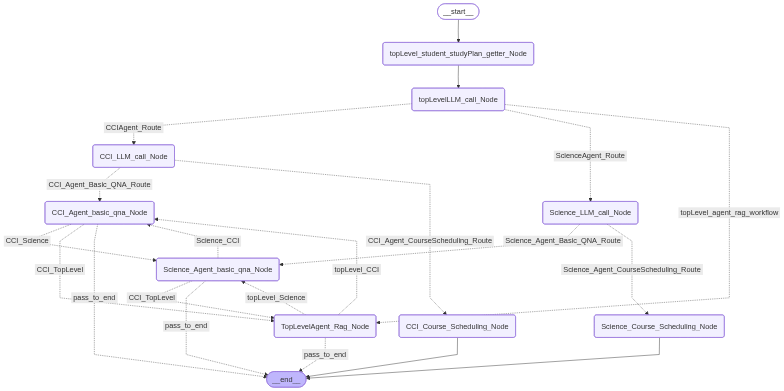

In [134]:
mainWorkingGaph

In [135]:
from IPython.display import display, HTML
import uuid

div_id = f"mermaid-{uuid.uuid4().hex}"

# Get Mermaid code from your graph
mermaid_code = mainWorkingGaph.get_graph().draw_mermaid()

html_code = f"""
<div style="width:1600px; height:auto;">
  <div id="{div_id}" class="mermaid">
    {mermaid_code}
  </div>
</div>

<script type="module">
import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
mermaid.initialize({{ startOnLoad:true }});
mermaid.run({{ 
    nodes: document.querySelectorAll('#{div_id}')
}});
</script>
"""

display(HTML(html_code))

In [136]:
Persone_1_initial_state_CCI_Business_Info_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 1,
    "yearOfStudy": 1,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Business_Information_Systems",
    "studentAlreadyCompletedCourses": [],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "Can you please schedule the courses for this semester for me in total of 25 credit Hour? " # "Can you please schedule the courses for this semester for me? ",
}

Persone_2_initial_state_CCI_BSc_Computer_Science_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Sophomore",
    "semester": 3,
    "yearOfStudy": 1,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Computer_Science",
    "studentAlreadyCompletedCourses": [
        '1501-100', '1440-131', '1430-110', '1430-116', '1501-116', '1420-101', '1420-102', '1440-132', '0104-100', '1501-211', '1502-201', '1501-279', '1440-281', '1501-246', '1501-215',
    ],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "Can you please schedule the courses for this semester for me? ",
}

Persone_3_initial_state_CCI_BSc_IT_Multimedia_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Sophomore",
    "semester": 4,
    "yearOfStudy": 2,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Computer_Science",
    "studentAlreadyCompletedCourses": [
        '1501-100', '1440-131', '1430-110', '1430-116', '1501-116', '1420-101', '1420-102', '1440-132', '0104-100', '1501-211', '1502-201', '1501-279', '1440-281', '1501-246', '1501-215', '1502-202', '1501-252', '1440-211', '0204-102', '1501-341', '1501-342', '1501-343', '1501-344', '1501-355',
    ],
    "StudentAlreadyCompletedCredits" : 57,
    "student_query": "Can you please schedule the courses for this semester for me in total of 25 credit Hour? ",
}


result = mainWorkingGaph.invoke(Persone_1_initial_state_CCI_Business_Info_Department)
print(result)

# get the ouput based on the routing decision
if result['topLevelAgent_basicConversationOrNot']==True: 
    print(result['basic_Conversation_answer'])

else: 
    if result['UOS_AgentState_top_level_decision']=='CCIAgent':
        if result['UOS_AgentState_CCIAgent_decision'] == 'CCI_Conversation': 
            print(result['CCI_Basic_QNA_RAG_Answer'])
            
        elif result['UOS_AgentState_CCIAgent_decision'] == 'CCI_CourseScheduling_advising':
            print(result["CCI_FinalScheduler_texts_LLM"].content)
            
    elif result['UOS_AgentState_top_level_decision']=='ScienceAgent':
        if result['UOS_AgentState_ScienceAgent_decision'] == 'Science_Conversation':
            print(result['Science_Basic_QNA_RAG_Answer'])

        elif result['UOS_AgentState_ScienceAgent_decision'] == 'Science_CourseScheduling_advising':
            print(result["Science_FinalScheduler_texts_LLM"].content)

1. Start Scheduling Courses for student!!
2. Communicating with Other Agent and fetching Courses offered by other Colleges!!!
3. Filtering the courses that has completed by this student and those courses that are not in student study plan
4. Start Organizing the filtered courses for LLM Processor. 
5. Offered, filtered and organized courses from Universiry are passes to Agent to schedule!!!
6. Course Scheduling Done for this Student. 
{'uid': 'U22106802', 'mensOrWomCampus': 'mens', 'standing': 'Freshman', 'yearOfStudy': 1, 'semester': 1, 'college': 'College of Computing and Informatics', 'department': 'BSc_Business_Information_Systems', 'studentAlreadyCompletedCourses': [], 'StudentAlreadyCompletedCredits': 0, 'student_query': 'Can you please schedule the courses for this semester for me in total of 25 credit Hour? ', 'remaining_course_in_study_plan': [{'course_code': '0301-120', 'course_title': 'Accounting (1): Financial Accounting', 'prerequisites': [], 'course_semester': 'Year 1 - S

In [137]:
Persone_1_initial_state_Science_Math_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 3,
    "yearOfStudy": 4,
    "college": "College of Science", 
    "department" : "BSc_Mathematics",
    "studentAlreadyCompletedCourses": [
        '0201-102', '1501-100', '1430-115', '1430-116', '1440-131', '0202-112', '1420-101', '1420-102', '1440-132',
        '1440-211', '0104-100', '1501-211', '1440-491'
    ],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "Can you please schedule the courses for this semester for me? ",
}

Persone_2_initial_state_Science_Chemistry_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 3,
    "yearOfStudy": 4,
    "college": "College of Science", 
    "department" : "BSc_Chemistry",
    "studentAlreadyCompletedCourses": [],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "Can you please schedule the courses for this semester for me? ",
}

Persone_3_initial_state_Science_Petroleum_Geosciences_and_Remote_Sensing_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 1,
    "yearOfStudy": 1,
    "college": "College of Science", 
    "department" : "BSc_Petroleum_Geosciences_and_Remote_Sensing",
    "studentAlreadyCompletedCourses": [
        '0201-102', '0201-105', '0202-112', '1460-120', '1430-110', '1430-116', '1440-131', '1411-100', '1420-101', '1420-102', '0202-207', '1430-117', 
        '1430-118', '1440-132', '1411-116', '1460-220', '1460-221', '0104-101', '1460-230',
    ],
    "StudentAlreadyCompletedCredits" : 57,
    "student_query": "Can you please schedule the courses offered in this semester for me? ",
}

Persone_4_initial_state_BSc_Biotechnology_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 5,
    "yearOfStudy": 3,
    "college": "College of Science", 
    "department" : "BSc_Biotechnology",
    "studentAlreadyCompletedCourses": [
        '0104-100','0201-102','0202-112','1426-155','1450-101','1450-107','1411-100'

    ],
    "StudentAlreadyCompletedCredits" : 63,
    "student_query": "Can you please schedule the courses offered in this semester for me in total of 15 Credit hour? ",
}

result = mainWorkingGaph.invoke(Persone_1_initial_state_Science_Math_Department)

# get the ouput based on the routing decision
if result['topLevelAgent_basicConversationOrNot']==True: 
    print(result['basic_Conversation_answer'])

else: 
    if result['UOS_AgentState_top_level_decision']=='CCIAgent':
        if result['UOS_AgentState_CCIAgent_decision'] == 'CCI_Conversation': 
            print(result['CCI_Basic_QNA_RAG_Answer'])
            
        elif result['UOS_AgentState_CCIAgent_decision'] == 'CCI_CourseScheduling_advising':
            print(result["CCI_FinalScheduler_texts_LLM"].content)
            
    elif result['UOS_AgentState_top_level_decision']=='ScienceAgent':
        if result['UOS_AgentState_ScienceAgent_decision'] == 'Science_Conversation':
            print(result['Science_Basic_QNA_RAG_Answer'])

        elif result['UOS_AgentState_ScienceAgent_decision'] == 'Science_CourseScheduling_advising':
            print(result["Science_FinalScheduler_texts_LLM"].content)

UOS_AgentState_ScienceAgent_decision:  Science_CourseScheduling_advising
1. Start Scheduling Courses for student!!
2. Communicating with Other Agent and fetching Courses offered by other Colleges!!!
3. Filtering the courses that has completed by this student and those courses that are not in student study plan
4. Start Organizing the filtered courses for LLM Processor. 
5. Offered, filtered and organized courses from Universiry are passes to Agent to schedule!!!
6. Course Scheduling Done for this Student. 
```json
[
  {
    "course_code": "1440-241",
    "course_title": "Ordinary Differential Equations I",
    "credit_hours": 3,
    "meeting_days": "Monday, Wednesday, Friday",
    "meeting_time": "10:00-11:00",
    "campus": "Main Campus",
    "section": "A"
  },
  {
    "course_code": "1501-215",
    "course_title": "Data Structures",
    "credit_hours": 3,
    "meeting_days": "Tuesday, Thursday",
    "meeting_time": "11:00-12:00",
    "campus": "Main Campus",
    "section": "B"
  },


### Lets do some basic QNA

In [138]:
Persone_1_initial_state_basicQNA = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 1,
    "yearOfStudy": 1,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Business_Information_Systems",
    "studentAlreadyCompletedCourses": [],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "How many colleges are there in University of Sharjah? "
}

result = mainWorkingGaph.invoke(Persone_1_initial_state_basicQNA)

# get the ouput based on the routing decision
if result['topLevelAgent_basicConversationOrNot']==True: 
    print(result['basic_Conversation_answer'])

else: 
    if result['UOS_AgentState_top_level_decision']=='CCIAgent':
        if result['UOS_AgentState_CCIAgent_decision'] == 'CCI_Conversation': 
            print(result['CCI_Basic_QNA_RAG_Answer'])
            
        elif result['UOS_AgentState_CCIAgent_decision'] == 'CCI_CourseScheduling_advising':
            print(result["CCI_FinalScheduler_texts_LLM"].content)
            
    elif result['UOS_AgentState_top_level_decision']=='ScienceAgent':
        if result['UOS_AgentState_ScienceAgent_decision'] == 'Science_Conversation':
            print(result['Science_Basic_QNA_RAG_Answer'])

        elif result['UOS_AgentState_ScienceAgent_decision'] == 'Science_CourseScheduling_advising':
            print(result["Science_FinalScheduler_texts_LLM"].content)

The University of Sharjah has 15 colleges. 

Here is the list of colleges:

1. College of Sharia and Islamic Studies
2. College of Arts, Humanities and Social Sciences
3. College of Business Administration
4. College of Engineering
5. College of Health Sciences
6. College of Law
7. College of Fine Arts and Design
8. College of Communication
9. College of Medicine
10. College of Dental Medicine
11. College of Pharmacy
12. College of Sciences
13. College of Graduate Studies
14. College of Computing and Informatics
15. College of Public Policy


In [ ]:
Persone_2_initial_state_basicQNA = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 1,
    "yearOfStudy": 1,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Business_Information_Systems",
    "studentAlreadyCompletedCourses": [],
    "StudentAlreadyCompletedCredits" : 0,
    # "student_query": "is UAE Society compulsory course in Computer Science course? ",
    #"student_query": "How to register a course ? ",
    #"student_query": "can you tell me, how many credit I have completed till now? ",
    #"student_query": "What are the prerequisites before I can take the junior project?",
    #"student_query": "When can I register for my junior project?",
    #"student_query": "Can I take my internship before completing 66 credit hours?",
    #"student_query": "Can I take a course from another college as a free elective?",
    #"student_query": "What are the prerequisites before I can take the junior project?",
    #"student_query": "What are mark distribution for Cloud Computing course?",
    "student_query":  "What are mark distribution for programing 1 course?",
}

result = mainWorkingGaph.invoke(Persone_2_initial_state_basicQNA)
print(result) 

Connecting with Science Agent to get the related information regarding to student question
Gathered All information from Science Agent and Top-Level Agent: Now In Science Agent moving -> CCI Agent
Connecting with Top-Level Agent Knowledge-bank to get the related information regarding to student question
{'uid': 'U22106802', 'mensOrWomCampus': 'mens', 'standing': 'Freshman', 'yearOfStudy': 1, 'semester': 1, 'college': 'College of Computing and Informatics', 'department': 'BSc_Business_Information_Systems', 'studentAlreadyCompletedCourses': [], 'StudentAlreadyCompletedCredits': 0, 'student_query': 'can you tell me, how many credit I have completed till now? ', 'remaining_course_in_study_plan': [{'course_code': '0301-120', 'course_title': 'Accounting (1): Financial Accounting', 'prerequisites': [], 'course_semester': 'Year 1 - Semester 1'}, {'course_code': '0302-160', 'course_title': 'Principles of Management', 'prerequisites': [], 'course_semester': 'Year 1 - Semester 1'}, {'course_code'

In [146]:
if result['topLevelAgent_basicConversationOrNot']==True: 
    print(result['basic_Conversation_answer'])

else: 
    if result['UOS_AgentState_top_level_decision']=='CCIAgent':
        if result['UOS_AgentState_CCIAgent_decision'] == 'CCI_Conversation': 
            print(result['CCI_Basic_QNA_RAG_Answer'])
            
        elif result['UOS_AgentState_CCIAgent_decision'] == 'CCI_CourseScheduling_advising':
            print(result["CCI_FinalScheduler_texts_LLM"].content)
            
    elif result['UOS_AgentState_top_level_decision']=='ScienceAgent':
        if result['UOS_AgentState_ScienceAgent_decision'] == 'Science_Conversation':
            print(result['Science_Basic_QNA_RAG_Answer'])

        elif result['UOS_AgentState_ScienceAgent_decision'] == 'Science_CourseScheduling_advising':
            print(result["Science_FinalScheduler_texts_LLM"].content)

According to your Student Personal Information, you are a freshman in the College of Computing and Informatics, Department of BSc_Business_Information_Systems, and you have completed 0 credit hours.

To answer your question: You have completed 0 credit hours till now. 

This information can be verified from your Student Personal Information. The retrieved texts about various courses and programs in the university do not affect your personal information regarding completed credit hours.


## Build and API gateway to access the model

In [ ]:
import nest_asyncio
from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.middleware.cors import CORSMiddleware
import uvicorn


In [ ]:
app = FastAPI()
nest_asyncio.apply()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # Allow all origins (change this in production)
    allow_credentials=True,
    allow_methods=["*"],  # Allow all HTTP methods
    allow_headers=["*"],  # Allow all headers
)

class QueryRequest(BaseModel):
    query: str


@app.get("/")
def home():
    return {"answer": "FastAPI is running!"}


@app.post("/askQuestion")
@app.post("/askQuestion/")
def askQuestion(data: QueryRequest): 
    query = data.query

    studentDummyQuery= {
        "uid": "U22106802", 
        "mensOrWomCampus" : "mens",
        "standing": "Freshman",
        "semester": 1,
        "yearOfStudy": 1,
        "college": "College of Computing and Informatics", 
        "department" : "BSc_Business_Information_Systems",
        "studentAlreadyCompletedCourses": [
            '0104-100','0201-102','0202-112','1426-155','1450-101','1450-107','1411-100'
        ],
        "StudentAlreadyCompletedCredits" : 23,
        "student_query": query,
    }

    agent_Response = mainWorkingGaph.invoke(studentDummyQuery)

    if agent_Response['topLevelAgent_basicConversationOrNot']==True: 
        answer = agent_Response['basic_Conversation_answer'] 

    else: 
        if agent_Response['UOS_AgentState_top_level_decision']=='CCIAgent':
            if agent_Response['UOS_AgentState_CCIAgent_decision'] == 'CCI_Conversation': 
                answer = agent_Response['CCI_Basic_QNA_RAG_Answer']
                
            elif agent_Response['UOS_AgentState_CCIAgent_decision'] == 'CCI_CourseScheduling_advising':
                answer = agent_Response['CCI_FinalScheduler_texts_LLM'].content
                
        elif agent_Response['UOS_AgentState_top_level_decision']=='ScienceAgent':
            if agent_Response['UOS_AgentState_ScienceAgent_decision'] == 'Science_Conversation':
                answer = agent_Response['Science_Basic_QNA_RAG_Answer']

            elif agent_Response['UOS_AgentState_ScienceAgent_decision'] == 'Science_CourseScheduling_advising':
                answer = agent_Response['Science_FinalScheduler_texts_LLM'].content


    #answer = answer.split("\n")
    #breakLineAns = "" 
    #for ans in answer:
    #    breakLineAns += ans + "<br>"
    #return {"answer": breakLineAns}
    return {"answer": answer}


In [ ]:
import socket

ip_address = socket.gethostbyname(socket.gethostname())
print(f"Your local IP address: {ip_address}")

In [ ]:
config = uvicorn.Config(app, host="0.0.0.0", port=8000)
server = uvicorn.Server(config)

await server.serve()